In [1]:
import os
import pandas as pd
import yfinance as yf

os.makedirs("data", exist_ok=True)

In [2]:
stocks = {
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "TCS",
    "INFY.NS": "Infosys",
    "HDFCBANK.NS": "HDFC Bank",
    "ICICIBANK.NS": "ICICI Bank"
}

In [3]:
def fetch_news_yfinance(stocks):
    all_news = []

    for ticker, company in stocks.items():
        print(f"Fetching news for {ticker}...")

        stock = yf.Ticker(ticker)
        news = stock.news

        if not news:
            continue

        for article in news:

            title = article.get("title")
            date = article.get("providerPublishTime")
            source = article.get("publisher")


            if not title:
                content = article.get("content", {})
                title = content.get("title")
                date = content.get("pubDate")
                source = content.get("provider", {}).get("displayName")

            all_news.append({
                "date": date,
                "title": title,
                "source": source,
                "company": company,
                "ticker": ticker
            })

    df = pd.DataFrame(all_news)
    return df

In [7]:
news_df = fetch_news_yfinance(stocks)


news_df.dropna(subset=["title"], inplace=True)

print(news_df.shape)
news_df.head()

Fetching news for RELIANCE.NS...
Fetching news for TCS.NS...
Fetching news for INFY.NS...
Fetching news for HDFCBANK.NS...
Fetching news for ICICIBANK.NS...
(50, 5)


,date,title,source,company,ticker
0,2026-04-06T14:53:53Z,India's Reliance buys Venezuelan oil directly ...,Reuters,Reliance Industries,RELIANCE.NS
1,2026-04-03T14:07:15Z,How The Investment Story For Reliance Industri...,Simply Wall St.,Reliance Industries,RELIANCE.NS
2,2026-04-01T01:51:53Z,India diesel exports to SE Asia hit 7-year hig...,Reuters,Reliance Industries,RELIANCE.NS
3,2026-03-26T12:28:31Z,OpenAI Appoints JioStar CEO to Lead Asia Expan...,GuruFocus.com,Reliance Industries,RELIANCE.NS
4,2026-03-24T10:06:43Z,Exclusive-India's Reliance buys 5 million barr...,Reuters,Reliance Industries,RELIANCE.NS


In [5]:
news_df.to_csv("data/news_data.csv", index=False)

In [8]:
def fetch_multiple_stocks(stocks_dict, period="1mo"):
    all_data = []
    for ticker in stocks_dict.keys():
        print(f"Downloading data for {ticker}...")
        data = yf.download(ticker, period=period)
        if not data.empty:
            data = data.reset_index()
            data["ticker"] = ticker
            all_data.append(data)
    return pd.concat(all_data, ignore_index=True)

stock_df = fetch_multiple_stocks(stocks)

print("Stock data shape:", stock_df.shape)
stock_df.head()

/tmp/ipykernel_16839/3621137954.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16839/3621137954.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16839/3621137954.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16839/3621137954.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16839/3621137954.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)


[*********************100%***********************]  1 of 1 completed

Stock data shape: (105, 27)


Price,Date,Close,High,Low,Open,Volume,ticker,Close,High,Low,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,TCS.NS,TCS.NS,TCS.NS,...,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS
0,2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-10,1408.800049,1431.500000,1400.599976,1430.599976,18071259.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-11,1390.199951,1434.000000,1383.599976,1424.900024,21848087.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-12,1392.199951,1410.900024,1381.099976,1390.000000,20939959.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-13,1380.699951,1400.800049,1378.400024,1385.199951,17265090.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
stock_df.to_csv("data/stock_data.csv", index=False)

In [10]:
!pip install transformers torch --quiet


import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [11]:
MODEL_NAME = "yiyanghkust/finbert-tone"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30873, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [12]:
news_df = pd.read_csv("data/news_data.csv")

In [13]:
def get_sentiment_batch(text_list):
    inputs = tokenizer(
        text_list,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    scores = torch.nn.functional.softmax(outputs.logits, dim=1)


    sentiment_scores = scores[:, 2] - scores[:, 0]

    return sentiment_scores.numpy()

In [14]:

news_sample = news_df.head(100).copy()

batch_size = 16
sentiments = []

titles = news_sample["title"].tolist()

for i in range(0, len(titles), batch_size):
    batch = titles[i:i+batch_size]
    scores = get_sentiment_batch(batch)
    sentiments.extend(scores)

news_sample["sentiment"] = sentiments

news_sample.head()

,date,title,source,company,ticker,sentiment
0,2026-04-06T14:53:53Z,India's Reliance buys Venezuelan oil directly ...,Reuters,Reliance Industries,RELIANCE.NS,-0.999980
1,2026-04-03T14:07:15Z,How The Investment Story For Reliance Industri...,Simply Wall St.,Reliance Industries,RELIANCE.NS,-0.999541
2,2026-04-01T01:51:53Z,India diesel exports to SE Asia hit 7-year hig...,Reuters,Reliance Industries,RELIANCE.NS,0.996903
3,2026-03-26T12:28:31Z,OpenAI Appoints JioStar CEO to Lead Asia Expan...,GuruFocus.com,Reliance Industries,RELIANCE.NS,-0.982704
4,2026-03-24T10:06:43Z,Exclusive-India's Reliance buys 5 million barr...,Reuters,Reliance Industries,RELIANCE.NS,-0.998926


In [15]:
batch_size = 16
sentiments = []

titles = news_df["title"].tolist()

for i in range(0, len(titles), batch_size):
    batch = titles[i:i+batch_size]
    scores = get_sentiment_batch(batch)
    sentiments.extend(scores)

news_df["sentiment"] = sentiments

In [16]:
news_df.to_csv("data/news_with_sentiment.csv", index=False)

In [17]:
news_df = pd.read_csv("data/news_with_sentiment.csv")
stock_df = pd.read_csv("data/stock_data.csv")

print(news_df.shape, stock_df.shape)

(50, 6) (106, 27)


In [18]:

stock_df = stock_df.reset_index(drop=True)
stock_df = stock_df.loc[:, ~stock_df.columns.duplicated()]


news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce")
stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce")


news_df = news_df.dropna(subset=["date", "sentiment"])

In [19]:

news_df = news_df.sort_values("date")
stock_df = stock_df.sort_values("Date")

In [20]:
news_df = news_df.dropna(subset=["date"])
stock_df = stock_df.dropna(subset=["Date"])

In [21]:

news_df["date"] = news_df["date"].dt.tz_localize(None)


stock_df["Date"] = pd.to_datetime(stock_df["Date"]).dt.tz_localize(None)

In [22]:

stock_df["Close"] = pd.to_numeric(stock_df["Close"], errors="coerce")


stock_df = stock_df.sort_values(["ticker", "Date"])


stock_df["next_close"] = stock_df.groupby("ticker")["Close"].shift(-1)


stock_df["return"] = (
    (stock_df["next_close"] - stock_df["Close"]) / stock_df["Close"]
)

In [23]:
stock_df = stock_df.reset_index(drop=True)
news_df = news_df.reset_index(drop=True)

In [24]:

stock_df = stock_df.sort_values("Date")
news_df = news_df.sort_values("date")

merged_df = pd.merge_asof(
    news_df,
    stock_df,
    left_on="date",
    right_on="Date",
    by="ticker",
    direction="forward"
)

In [25]:
print(merged_df.shape)
merged_df.head()

(50, 34)


,date,title,source,company,ticker,sentiment,Date,Close,High,Low,...,Low.3,Open.3,Volume.3,Close.4,High.4,Low.4,Open.4,Volume.4,next_close,return
0,2026-02-23 17:09:52,"ServiceNow, TCS Expand AI Alliance",GuruFocus.com,TCS,TCS.NS,-0.999124,2026-03-09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-02-23 17:57:15,ServiceNow Signs Multi Year AI Partnership Wit...,GuruFocus.com,TCS,TCS.NS,-0.999116,2026-03-09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-02-23 19:11:54,ServiceNow AI Alliances With TCS And Kearney D...,Simply Wall St.,TCS,TCS.NS,-0.999325,2026-03-09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-02-24 13:51:54,India's Tata Sons delays chairman decision aft...,Reuters,TCS,TCS.NS,0.980012,2026-03-09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-02-25 03:15:06,ServiceNow AI Push Deepens Enterprise Role Wit...,Simply Wall St.,TCS,TCS.NS,-0.997162,2026-03-09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
def generate_signal(sentiment):
    if sentiment > 0.3:
        return 1
    elif sentiment < -0.3:
        return -1
    else:
        return 0

merged_df["signal"] = merged_df["sentiment"].apply(generate_signal)

merged_df[["sentiment", "signal"]].head()

,sentiment,signal
0,-0.999124,-1
1,-0.999116,-1
2,-0.999325,-1
3,0.980012,1
4,-0.997162,-1


In [27]:
merged_df["strategy_return"] = merged_df["signal"] * merged_df["return"]

In [28]:
merged_df["cumulative_strategy"] = (1 + merged_df["strategy_return"]).cumprod()
merged_df["cumulative_market"] = (1 + merged_df["return"]).cumprod()

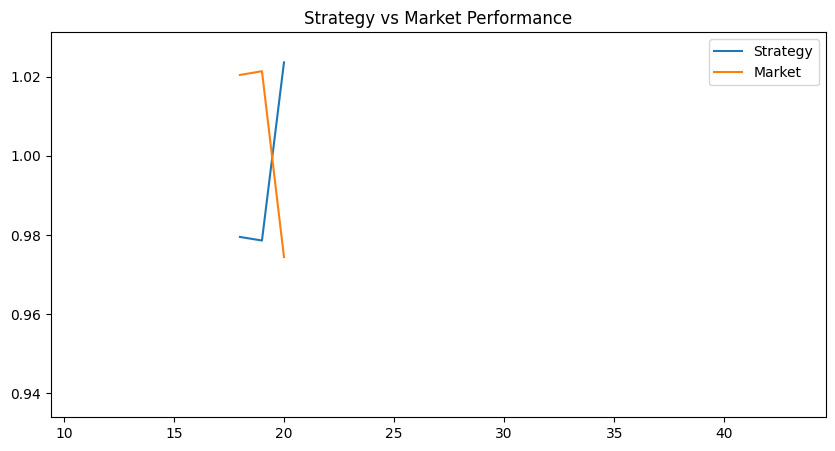

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(merged_df["cumulative_strategy"], label="Strategy")
plt.plot(merged_df["cumulative_market"], label="Market")

plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()

In [30]:
sharpe = merged_df["strategy_return"].mean() / merged_df["strategy_return"].std()
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -0.17153838249009837


In [31]:
cum = merged_df["cumulative_strategy"]
drawdown = (cum - cum.cummax()) / cum.cummax()

print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.06583248248682487
